In [13]:
import functions
import settings
import numpy as np
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import os

from keras_yamnet import params
from keras_yamnet.yamnet import YAMNet
import keras_yamnet.preprocessing as kp
from keras_yamnet.postprocessing import postprocess_output
from sklearn.model_selection import train_test_split

from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import PredefinedSplit

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import torch
import soundfile as sf
import platform
import time  
from tqdm import tqdm
import pickle
from pathlib import Path

import h5py
from sklearn.utils import shuffle
from sed_eval.sound_event import EventBasedMetrics, SegmentBasedMetrics
from dataset import gt_conversion_functions as cf
import settings
import importlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl

In [8]:
# Load dataset
importlib.reload(functions)

radius_results_280126_loc_1 = {}
radius_results_280126_loc_2 = {}
radius_results_280126_loc_3 = {}

for km, data_pair in settings.data_pairs_280126_loc_1_by_radius.items():
    X_radius, y_radius, folds_radius = functions.get_data_from_dict(data_pair, force_reload=False)
    radius_results_280126_loc_1[km] = (X_radius, y_radius, folds_radius)

for km, data_pair in settings.data_pairs_280126_loc_2_by_radius.items():
    X_radius, y_radius, folds_radius = functions.get_data_from_dict(data_pair, force_reload=False)
    radius_results_280126_loc_2[km] = (X_radius, y_radius, folds_radius)

for km, data_pair in settings.data_pairs_280126_loc_3_by_radius.items():
    X_radius, y_radius, folds_radius = functions.get_data_from_dict(data_pair, force_reload=False)
    radius_results_280126_loc_3[km] = (X_radius, y_radius, folds_radius)


radius_results_230226_loc_1 = {}
radius_results_230226_loc_2 = {}
radius_results_230226_loc_3 = {}

for km, data_pair in settings.data_pairs_230226_loc_1_by_radius.items():
    X_radius, y_radius, folds_radius = functions.get_data_from_dict(data_pair, force_reload=False)
    radius_results_230226_loc_1[km] = (X_radius, y_radius, folds_radius)

for km, data_pair in settings.data_pairs_230226_loc_2_by_radius.items():
    X_radius, y_radius, folds_radius = functions.get_data_from_dict(data_pair, force_reload=False)
    radius_results_230226_loc_2[km] = (X_radius, y_radius, folds_radius)

for km, data_pair in settings.data_pairs_230226_loc_3_by_radius.items():
    X_radius, y_radius, folds_radius = functions.get_data_from_dict(data_pair, force_reload=False)
    radius_results_230226_loc_3[km] = (X_radius, y_radius, folds_radius)


X_test, y_test, folds_test = functions.get_data_from_dict(settings.data_pairs_test, force_reload=False)
X_train, y_train, folds_train = functions.get_data_from_dict(settings.data_pairs_train, force_reload=False)
X_env, y_env, folds_env = functions.get_data_from_dict(settings.data_pairs_env, force_reload=False)

x_bytes = X_train.nbytes
print("X(train) size GB:", x_bytes / 1024**3)

print("Percentage 'Aircraft' in train:", np.sum(y_train) / len(y_train) * 100)
print("Percentage 'Aircraft' in env:", np.sum(y_env) / len(y_env) * 100)
print("Percentage 'Aircraft' in test:", np.sum(y_test) / len(y_test) * 100)

# Inspect fold distribution before training
print("=== Fold Diagnostic ===")
print(f"folds_train type: {type(folds_train)}, dtype: {folds_train.dtype if hasattr(folds_train, 'dtype') else 'N/A'}")
print(f"folds_train shape: {folds_train.shape if hasattr(folds_train, 'shape') else len(folds_train)}")

if folds_train is not None:
    unique_folds = np.unique(folds_train)
    print(f"Unique fold IDs: {unique_folds}")
    print(f"Number of unique folds: {len(unique_folds)}")
    
    # Count samples per fold
    for fold_id in sorted(unique_folds):
        count = np.sum(folds_train == fold_id)
        pos_count = np.sum(y_train[folds_train == fold_id])
        print(f"  Fold {fold_id}: {count} samples, {pos_count} positives ({pos_count/count*100:.1f}%)")
    
    # Check for any suspicious values (NaN, inf, etc.)
    if np.any(np.isnan(folds_train)):
        print("WARNING: NaN values found in folds_train!")
    if np.any(np.isinf(folds_train)):
        print("WARNING: Inf values found in folds_train!")
    
    print(f"\nPredefinedSplit will create {len(np.unique(folds_train))} fold splits")
else:
    print("folds_train is None")

# Remove fold 0 samples
if folds_train is not None:
    initial_count = len(X_train)
    keep_idx = folds_train != 0
    num_removed = np.sum(~keep_idx)
    num_kept = np.sum(keep_idx)
    percent_removed = (num_removed / initial_count) * 100
    
    X_train = X_train[keep_idx]
    y_train = y_train[keep_idx]
    folds_train = folds_train[keep_idx]
    
    print(f"Removed {num_removed} samples with fold=0 ({percent_removed:.1f}%)")
    print(f"Remaining samples: {num_kept}")
    print(f"New X_train shape: {X_train.shape}")
    print(f"New unique folds: {np.unique(folds_train)}")
else:
    print("No fold information available, skipping fold 0 removal")

Monitoring for 1 classes: ['Aircraft']
Loading cached result from C:/Users/kampfly/Documents/Ingeborg/Masteroppgave\280126\loc_1_280126_AUTOSAVE_sphere_1.0KM_Unfiltered.npz ...
Loading cached result from C:/Users/kampfly/Documents/Ingeborg/Masteroppgave\280126\loc_1_280126_AUTOSAVE_sphere_2.0KM_Unfiltered.npz ...
Loading cached result from C:/Users/kampfly/Documents/Ingeborg/Masteroppgave\280126\loc_1_280126_AUTOSAVE_sphere_3.0KM_Unfiltered.npz ...
Loading cached result from C:/Users/kampfly/Documents/Ingeborg/Masteroppgave\280126\loc_1_280126_AUTOSAVE_sphere_4.0KM_Unfiltered.npz ...
Loading cached result from C:/Users/kampfly/Documents/Ingeborg/Masteroppgave\280126\loc_1_280126_AUTOSAVE_sphere_5.0KM_Unfiltered.npz ...
Loading cached result from C:/Users/kampfly/Documents/Ingeborg/Masteroppgave\280126\loc_1_280126_AUTOSAVE_sphere_6.0KM_Unfiltered.npz ...
Loading cached result from C:/Users/kampfly/Documents/Ingeborg/Masteroppgave\280126\loc_1_280126_AUTOSAVE_sphere_7.0KM_Unfiltered.npz

Loading gt: 100%|██████████| 21/21 [00:17<00:00,  1.21it/s]


Processing and caching in : C:/Users/kampfly/Documents/Ingeborg/Masteroppgave\230226\loc_3_230226_AUTOSAVE_sphere_8.0KM_Unfiltered.npz


Loading gt: 100%|██████████| 20/20 [00:08<00:00,  2.37it/s]


Processing and caching in : C:/Users/kampfly/Documents/Ingeborg/Masteroppgave\230226\loc_3_230226_AUTOSAVE_sphere_9.0KM_Unfiltered.npz


...

Processing and caching in : C:/Users/kampfly/Documents/Ingeborg/Masteroppgave\230226\loc_3_230226_AUTOSAVE_sphere_14.0KM_Unfiltered.npz


Loading gt: 100%|██████████| 22/22 [00:06<00:00,  3.15it/s]


Processing and caching in : C:/Users/kampfly/Documents/Ingeborg/Masteroppgave\230226\loc_3_230226_AUTOSAVE_sphere_15.0KM_Unfiltered.npz


Saving y to cache: 100%|██████████| 15111/15111 [00:00<00:00, 24936.54it/s]


Loading cached result from c:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\dataset\AeroSonicDB/gt_test_Unfiltered.npz ...
Loading cached result from c:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\dataset\AeroSonicDB/gt_train_Unfiltered.npz ...
Loading cached result from c:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\dataset\AeroSonicDB/env_audio_gt_Unfiltered.npz ...
X(train) size GB: 3.7349853515625
Percentage 'Aircraft' in train: 66.77860574566134
Percentage 'Aircraft' in env: 17.34240241842269
Percentage 'Aircraft' in test: 59.57692307692307
=== Fold Diagnostic ===
folds_train type: <class 'numpy.ndarray'>, dtype: int32
folds_train shape: (81592,)
Unique fold IDs: [0 1 2 3 4 5]
Number of unique folds: 6
  Fold 0: 10024 samples, 0.0 positives (0.0%)
  Fold 1: 13976 samples, 10826.0 positives (77.5%)
  Fold 2: 13393 samples, 11199.0 positives (83.6%)
  Fold 3: 14619 samples, 1

In [9]:
""" Build model """

importlib.reload(settings) 

yamnet_full = YAMNet(include_top=True, weights='keras_yamnet/yamnet.h5')
yamnet_backbone = tf.keras.Model(
    inputs=yamnet_full.input,
    outputs=yamnet_full.get_layer("global_average_pooling2d").output
)
yamnet_backbone.trainable = True

patch_shape = (params.PATCH_FRAMES, params.PATCH_BANDS)
inp = tf.keras.Input(shape=patch_shape, name='patch_input')

emb = yamnet_backbone(inp)  # (None, 1024)

x = tf.keras.layers.Dense(512, activation='relu', name='clf_dense', kernel_regularizer=tf.keras.regularizers.L2(0.001))(emb)
x = tf.keras.layers.Dropout(0.4, name='clf_dropout')(x)
outputs = tf.keras.layers.Dense(settings.N_CLASSES, activation='sigmoid', name='output')(x)  # logits; use from_logits=True

model = tf.keras.Model(inputs=inp, outputs=outputs, name='MergedYAMNet_E2E_Single')

model.summary()

# Explicitly check output layer activation
last_layer = model.layers[-1]
print("Last layer:", last_layer.name)
print("Activation:", last_layer.activation.__name__)

# Optional: print all layers + activations
for i, layer in enumerate(model.layers):
    act = getattr(layer, "activation", None)
    act_name = act.__name__ if act is not None else "None"
    print(f"{i:02d} | {layer.name:35s} | activation={act_name}")

Monitoring for 1 classes: ['Aircraft']


Model: "MergedYAMNet_E2E_Single"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 patch_input (InputLayer)    [(None, 96, 64)]          0         
                                                                 
 model_1 (Functional)        (None, 1024)              3217344   
                                                                 
 clf_dense (Dense)           (None, 512)               524800    
                                                                 
 clf_dropout (Dropout)       (None, 512)               0         
                                                                 
 output (Dense)              (None, 1)                 513       
                                                                 
Total params: 3742657 (14.28 MB)
Trainable params: 3720769 (14.19 MB)
Non-trainable params: 21888 (85.50 KB)
_________________________

In [ ]:
""" Train the model """

importlib.reload(settings) 
print(f'Using threshold: {settings.PREDICTION_THRESHOLD}')
cross_validation = False
train_km = 2
X_train_all = np.concatenate([X_train, radius_results_280126_loc_1[train_km][0],radius_results_280126_loc_2[train_km][0], radius_results_280126_loc_3[train_km][0]], axis=0)
y_train_all = np.concatenate([y_train, radius_results_280126_loc_1[train_km][1],radius_results_280126_loc_2[train_km][1], radius_results_280126_loc_3[train_km][1]], axis=0)
X_train_all, X_val, y_train_all, y_val = train_test_split(
    X_train_all, y_train_all, test_size=0.2, random_state=42, shuffle=True
)
print(f'Class balance in combined train set: {np.sum(y_train_all)/len(y_train_all)*100:.2f}% Aircraft')
print(f"Class balance in combined val set: {np.sum(y_val==1)}/{len(y_val)} ({100*np.mean(y_val==1):.2f}% Aircraft)")


if __name__ == "__main__":

    device, device_type = functions.get_device()
    print(f"Using device: {device_type}")

    timestr = time.strftime("%Y%m%d-%H%M%S")

    os.makedirs('history', exist_ok=True)
    os.makedirs(f'history/{timestr}', exist_ok=True)

    model.compile(loss='binary_crossentropy',
                 optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4),
                 metrics=[
        tf.keras.metrics.Precision(thresholds=settings.PREDICTION_THRESHOLD, name='precision'),
        tf.keras.metrics.Recall(thresholds=settings.PREDICTION_THRESHOLD, name='recall'),
        tf.metrics.F1Score(threshold=settings.PREDICTION_THRESHOLD, average='macro', name='f1_score')
    ]
    )

    # Save the model with the best validation F1 score
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=f'history/{timestr}/best_model.keras',
        monitor='val_f1_score',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    # Early stop based on validation F1 score and restore best F1 weights
    callback = [
        tf.keras.callbacks.EarlyStopping(monitor='val_f1_score',
                                         patience=3,
                                         restore_best_weights=True),
        checkpoint_cb
    ]
    

    ps = PredefinedSplit(test_fold=folds_train)
    ap_scores_test = []
    ap_scores_env = []
    ap_scores_val = []
    pr_curves_skatval_280126 = []
    pr_curves_skatval_230226 = []


    pr_curves_test = []
    pr_curves_env = []
    pr_curves_val = []
    ap_scores_skatval_280126 = []
    ap_scores_skatval_230226 = []

    thresholds_280126 = []
    thresholds_230226 = []


    if cross_validation:
        for fold, (train_idx, val_idx) in enumerate(ps.split()):
            print(f"\nTraining on fold {fold + 1}/{ps.get_n_splits()}...")
            X_train_fold, y_train_fold = X_train[train_idx], y_train[train_idx]
            X_val_fold, y_val_fold = X_train[val_idx], y_train[val_idx]

            " Train the model"
            print("Val positives:", np.sum(y_val_fold)/len(y_val_fold) * 100, "%")

            print("Train positives:", np.sum(y_train_fold)/len(y_train_fold) * 100, "%")

            history = model.fit(X_train_fold, y_train_fold, validation_data=(X_val_fold, y_val_fold), batch_size=16,
                            epochs=100, callbacks=callback)
            
            "Validation metrics for this fold"
            val_predictions = model.predict(X_val_fold)
            val_ap = average_precision_score(y_val_fold, val_predictions, average='macro')
            val_precision, val_recall, _ = precision_recall_curve(y_val_fold.ravel(), val_predictions.ravel())
            pr_curves_val.append((val_precision, val_recall))
            ap_scores_val.append(val_ap)
            
            " Evaluate on test set"
            predictions = model.predict(X_test)
            ap = average_precision_score(y_test, predictions, average='macro')
            precision, recall, _ = precision_recall_curve(y_test.ravel(), predictions.ravel())
            pr_curves_test.append((precision, recall))
            ap_scores_test.append(ap)

            " Evaluate on environmental set"
            predictions_env = model.predict(X_env)
            ap = average_precision_score(y_env, predictions_env, average='macro')
            precision_env, recall_env, _ = precision_recall_curve(y_env.ravel(), predictions_env.ravel())
            pr_curves_env.append((precision_env, recall_env))
            ap_scores_env.append(ap)

            " Evaluate on Skatval location1 set"
            predictions_skatval_280126 = model.predict(X_skatval_280126)
            ap_280126 = average_precision_score(y_skatval_280126, predictions_skatval_280126, average='macro')
            precision_skatval_280126, recall_skatval_280126, threshold_280126 = precision_recall_curve(y_skatval_280126.ravel(), predictions_skatval_280126.ravel())
            thresholds_280126.append(threshold_280126[precision_skatval_280126.argmax()])
            pr_curves_skatval_280126.append((precision_skatval_280126, recall_skatval_280126))
            ap_scores_skatval_280126.append(ap_280126)

            """ " Evaluate on Skatval location2 set"
            predictions_skatval_230226 = model.predict(X_skatval_230226)
            ap_230226 = average_precision_score(y_skatval_230226, predictions_skatval_230226, average='macro')
            precision_skatval_230226, recall_skatval_230226, threshold_230226 = precision_recall_curve(y_skatval_230226.ravel(), predictions_skatval_230226.ravel())
            thresholds_230226.append(threshold_230226[precision_skatval_230226.argmax()])
            pr_curves_skatval_230226.append((precision_skatval_230226, recall_skatval_230226))
            ap_scores_skatval_230226.append(ap_230226) """
    else:
        print("\nTraining on all data without cross-validation...")
        history = model.fit(
            X_train_all, y_train_all,
            validation_data=(X_val, y_val),
            batch_size=16, epochs=100, callbacks=callback, shuffle=True
        )
        

    """ print(f"\nTest Set Average Precision Scores across folds: {ap_scores_test}")
    print(f"Environmental Set Average Precision Scores across folds: {ap_scores_env}")
    print(f"Skatval 28.01.26 Set Average Precision Scores across folds: {ap_scores_skatval_280126}")


    save_ap_and_pr_curves(ap_scores_test, pr_curves_test, "test", timestr)
    save_ap_and_pr_curves(ap_scores_env, pr_curves_env, "environmental", timestr)
    save_ap_and_pr_curves(ap_scores_skatval_280126, pr_curves_skatval_280126, "skatval_280126", timestr)
    save_ap_and_pr_curves(ap_scores_val, pr_curves_val, "validation", timestr) """

    """ plot_and_save_ap_scores(ap_scores_val, ap_scores_test, ap_scores_skatval_280126, timestr) """


Monitoring for 1 classes: ['Aircraft']
Using threshold: 0.3
Class balance in combined train set: 45.41% Aircraft
Class balance in combined val set: 11184/24203 (46.21% Aircraft)
Using device: cuda

Training on all data without cross-validation...
Epoch 1/100


In [ ]:
""" Load baseline model """
baseline_model = tf.keras.models.load_model('history/baseline-aerosonicdb/best_model.keras')

c:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\realtimevenv\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\realtimevenv\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


 1 km -> AP: 0.0000 | samples: 45333 | true positives: 0.0 | predicted positives: 2543
 2 km -> AP: 0.2137 | samples: 45333 | true positives: 654.0 | predicted positives: 2543
 3 km -> AP: 0.4094 | samples: 45333 | true positives: 1338.0 | predicted positives: 2543
 4 km -> AP: 0.2914 | samples: 45333 | true positives: 3616.0 | predicted positives: 2543
 5 km -> AP: 0.4238 | samples: 45333 | true positives: 16268.0 | predicted positives: 2543
 6 km -> AP: 0.5567 | samples: 45333 | true positives: 20686.0 | predicted positives: 2543
 7 km -> AP: 0.3352 | samples: 45333 | true positives: 20590.0 | predicted positives: 12822
 8 km -> AP: 0.7082 | samples: 45333 | true positives: 30930.0 | predicted positives: 2543
 9 km -> AP: 0.7163 | samples: 45333 | true positives: 31462.0 | predicted positives: 2543
10 km -> AP: 0.7334 | samples: 45333 | true positives: 32234.0 | predicted positives: 2543
11 km -> AP: 0.7440 | samples: 45333 | true positives: 32718.0 | predicted positives: 2543
12 km 

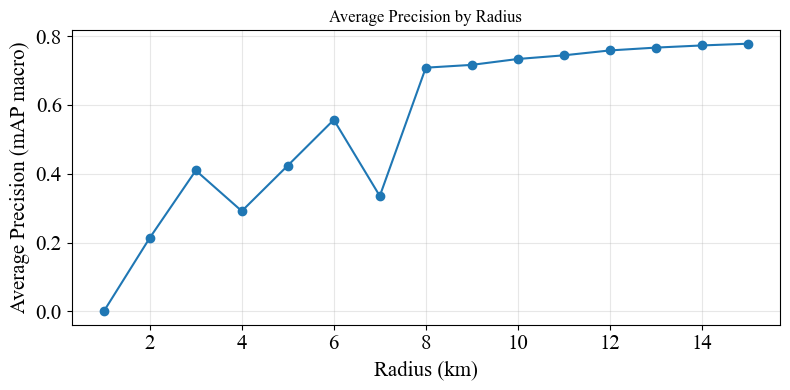

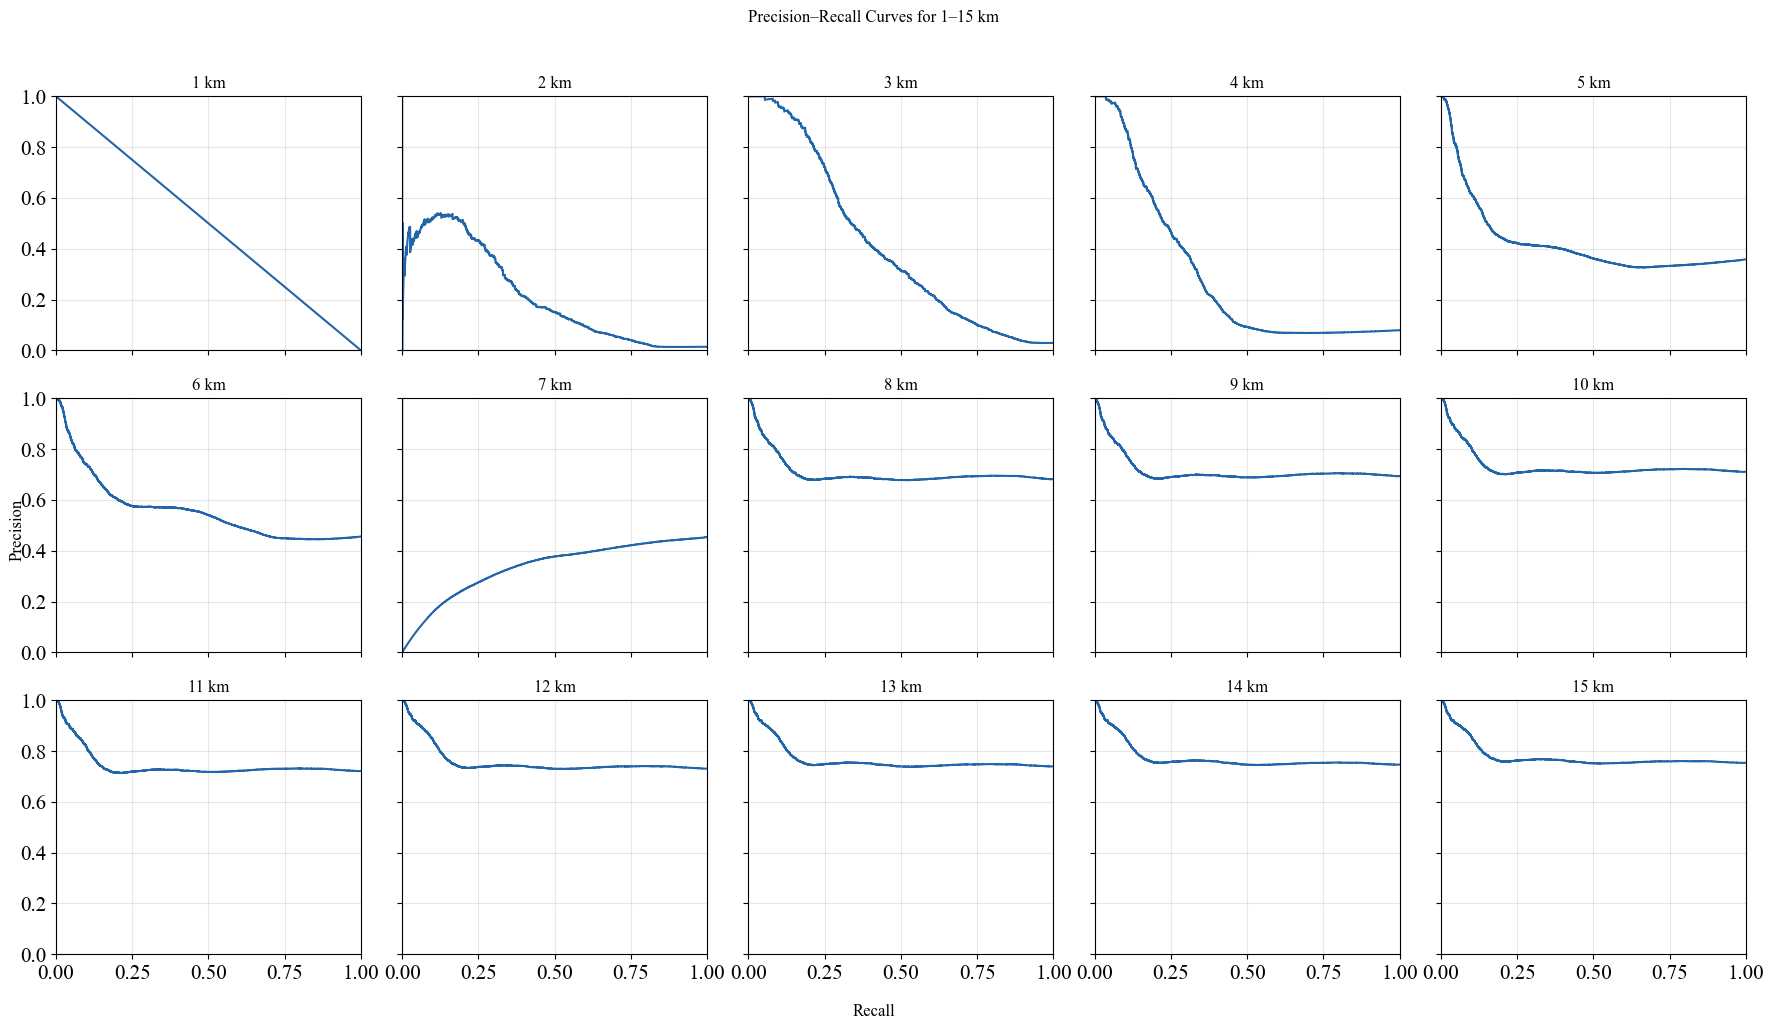

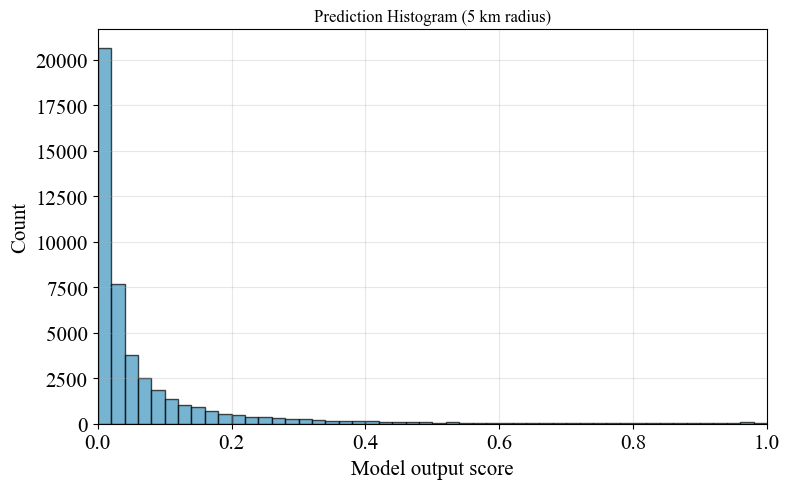

Saved histogram to history/baseline-aerosonicdb/histogram_5km.pdf


<Figure size 640x480 with 0 Axes>

In [12]:
import math

ap_scores_by_radius = {}
pr_curves_by_radius = {}
predictions_by_radius = {}

radii = list(range(1, 16))

for km in radii:
    if km not in radius_results_280126_loc_2:
        print(f"{km} km -> not found in radius_results, skipping")
        continue

    X_radius_loc1, y_radius_loc1, _ = radius_results_230226_loc_1[km]
    X_radius_loc2, y_radius_loc2, _ = radius_results_230226_loc_2[km]
    X_radius_loc3, y_radius_loc3, _ = radius_results_230226_loc_3[km]

    X_radius = np.concatenate([X_radius_loc1, X_radius_loc2, X_radius_loc3], axis=0)
    y_radius = np.concatenate([y_radius_loc1, y_radius_loc2, y_radius_loc3], axis=0)


    if len(y_radius) == 0:
        print(f"{km} km -> no samples, skipping")
        continue
    preds = model.predict(X_radius, verbose=0)

    ap = average_precision_score(y_radius, preds, average="macro")
    precision, recall, _ = precision_recall_curve(y_radius.ravel(), preds.ravel())

    ap_scores_by_radius[km] = ap
    pr_curves_by_radius[km] = (precision, recall)
    predictions_by_radius[km] = preds

    pred_binary = (preds >= settings.PREDICTION_THRESHOLD).astype(int)

    print(
        f"{km:2d} km -> "
        f"AP: {ap:.4f} | "
        f"samples: {len(y_radius)} | "
        f"true positives: {np.sum(y_radius)} | "
        f"predicted positives: {np.sum(pred_binary)}"
    )

# AP vs radius
plt.figure(figsize=(8, 4))
plt.plot(
    sorted(ap_scores_by_radius.keys()),
    [ap_scores_by_radius[k] for k in sorted(ap_scores_by_radius.keys())],
    marker="o"
)
plt.xlabel("Radius (km)")
plt.ylabel("Average Precision (mAP macro)")
plt.title("Average Precision by Radius")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# PR curves for 1-15 km
fig, axes = plt.subplots(3, 5, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, km in enumerate(radii):
    ax = axes[i]
    if km not in pr_curves_by_radius:
        ax.set_visible(False)
        continue

    precision, recall = pr_curves_by_radius[km]
    ax.plot(recall, precision, color="#2066a8")
    ax.set_title(f"{km} km")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

fig.supxlabel("Recall")
fig.supylabel("Precision")
fig.suptitle("Precision–Recall Curves for 1–15 km", y=1.02)
plt.tight_layout()
plt.show()

# Histogram for a single radius
km = 5  # Change this to 1, 2, 3, ..., 15 as needed

if km in predictions_by_radius:
    preds = predictions_by_radius[km].ravel()
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(preds, bins=50, range=(0, 1), color="#3e94be", edgecolor="black", alpha=0.7)
    ax.set_xlabel("Model output score")
    ax.set_ylabel("Count")
    ax.set_title(f"Prediction Histogram ({km} km radius)")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    # Optional: save to PDF
    plt.savefig(f"history/baseline-aerosonicdb/histogram_{km}km.pdf", format="pdf")
    print(f"Saved histogram to history/baseline-aerosonicdb/histogram_{km}km.pdf")
else:
    print(f"{km} km not found in predictions_by_radius")

Loading gt: 100%|██████████| 1/1 [00:00<00:00,  4.03it/s]


Processing and caching in : C:/Users/kampfly/Documents/Ingeborg/Masteroppgave/gt_bergen_Unfiltered.npz


Saving y to cache: 100%|██████████| 519/519 [00:00<00:00, 23596.71it/s]
c:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\realtimevenv\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\kampfly\Documents\Ingeborg\Prosjektoppgave\sound-event-detection-aircrafts\realtimevenv\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


Bergen -> AP: 0.0000 | samples: 519 | true positives: 0.0 | predicted positives: 499


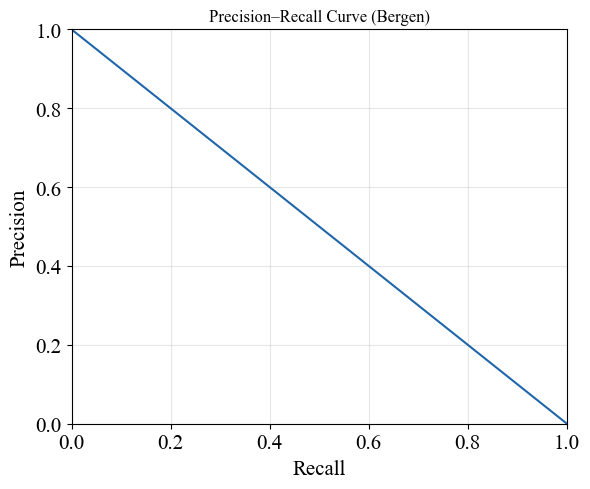

Saved PR curve to history/baseline-aerosonicdb\pr_curve_bergen.pdf


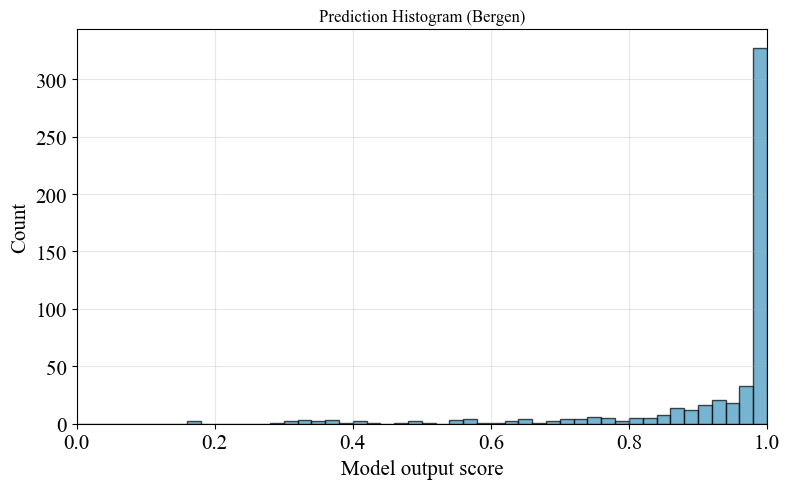

Saved histogram to history/baseline-aerosonicdb\histogram_bergen.pdf


In [15]:
importlib.reload(functions) 
X_bergen, y_bergen, folds_bergen = functions.get_data_from_dict(settings.data_pair_bergen, force_reload=True)


bergen_results = functions.evaluate_dataset(
    model=model,
    X=X_bergen,
    y=y_bergen,
    dataset_name="Bergen",
    output_dir="history/baseline-aerosonicdb",
    threshold=settings.PREDICTION_THRESHOLD,
    verbose=0,
    show_plots=True,
)

Thresholds for Skatval 28.01.26: [(0.9999829, 1.0, 1.0)]
Thresholds for Skatval 23.02.26: [(0.99987715, 1.0, 1.0), (0.9675421, 1.0, 1.0), (0.98583144, 1.0, 1.0), (0.99996567, 1.0, 1.0), (0.0006415543, 0.8465912704970502, 0.7339906911080228, 1.0), (0.0006415543, 0.8465912704970502, 0.7339906911080228, 1.0), (0.0006415543, 0.8465912704970502, 0.7339906911080228, 1.0)]


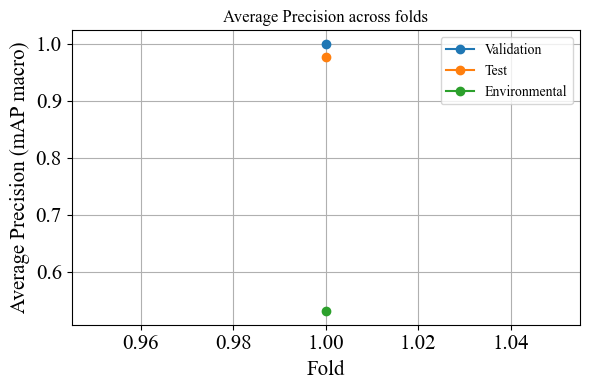

mAP val  : 0.9996948497839058 +/- 0.0
mAP test : 0.9758654182733524 +/- 0.0
mAP env  : 0.5300923364346809 +/- 0.0


(array([4811.,  515.,  307.,  224.,  156.,  115.,  104.,  109.,   87.,
          93.,   61.,   64.,   60.,   58.,   49.,   52.,   55.,   65.,
          67.,   51.,   74.,   72.,   57.,   54.,   51.,   34.,   38.,
          29.,   44.,   42.,   32.,   25.,   41.,   34.,   43.,   38.,
          40.,   31.,   40.,   58.,   51.,   56.,   80.,   65.,  107.,
         164.,  187.,  256.,  390., 8864.]),
 array([7.72102339e-06, 2.00074911e-02, 4.00072634e-02, 6.00070320e-02,
        8.00068006e-02, 1.00006573e-01, 1.20006345e-01, 1.40006110e-01,
        1.60005882e-01, 1.80005655e-01, 2.00005427e-01, 2.20005199e-01,
        2.40004972e-01, 2.60004729e-01, 2.80004501e-01, 3.00004274e-01,
        3.20004046e-01, 3.40003818e-01, 3.60003591e-01, 3.80003363e-01,
        4.00003135e-01, 4.20002908e-01, 4.40002680e-01, 4.60002452e-01,
        4.80002224e-01, 5.00001967e-01, 5.20001769e-01, 5.40001512e-01,
        5.60001314e-01, 5.80001056e-01, 6.00000858e-01, 6.20000601e-01,
        6.40000403e-01, 

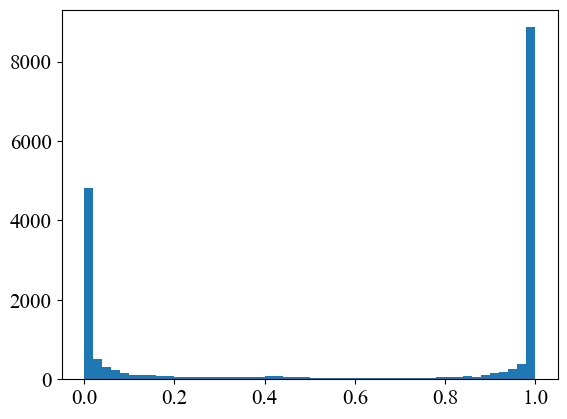

In [32]:
save_ap_and_pr_curves(ap_scores_test, pr_curves_test, "test", timestr)
save_ap_and_pr_curves(ap_scores_env, pr_curves_env, "environmental", timestr)
save_ap_and_pr_curves(ap_scores_skatval_280126, pr_curves_skatval_280126, "skatval", timestr)
save_ap_and_pr_curves(ap_scores_val, pr_curves_val, "validation", timestr)

print(f'Thresholds for Skatval 28.01.26: {thresholds_280126}')
print(f'Thresholds for Skatval 23.02.26: {thresholds_230226}')

plot_and_save_ap_scores(ap_scores_val, ap_scores_test, ap_scores_skatval_280126, timestr)


plt.hist(predictions.flatten(), bins=50)

In [10]:
prediction = model.predict(X_skatval_280126[0:20])

# Save predictions to cache
cache_file = f'history/{timestr}/predictions_skatval_280126.h5'
with h5py.File(cache_file, 'w') as f:
    f.create_dataset('predictions', data=prediction)
print(f"Predictions saved to {cache_file}")

1/1 [==============================] - 0s 39ms/step
Predictions saved to history/20260310-111945/predictions_skatval_280126.h5


In [ ]:
# Load model from saved checkpoint

model = tf.keras.models.load_model('history/20260310-111945/best_model.keras')
print(f"Model loaded successfully!")
print(f"Model summary:")
model.summary()

# Load variables from cache
ap_scores_test = functions.load_variable(f'history/{timestr}/ap_scores_test.pk1')
ap_scores_env = functions.load_variable(f'history/{timestr}/ap_scores_environmental.pk1')
ap_scores_val = functions.load_variable(f'history/{timestr}/ap_scores_validation.pk1')

Model loaded successfully!
Model summary:
Model: "MergedYAMNet_E2E_Single"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 patch_input (InputLayer)    [(None, 96, 64)]          0         
                                                                 
 model_1 (Functional)        (None, 1024)              3217344   
                                                                 
 clf_dense (Dense)           (None, 512)               524800    
                                                                 
 clf_dropout (Dropout)       (None, 512)               0         
                                                                 
 output (Dense)              (None, 1)                 513       
                                                                 
Total params: 3742657 (14.28 MB)
Trainable params: 3720769 (14.19 MB)
Non-trainable params: 21888 (85.50 KB)
________________________

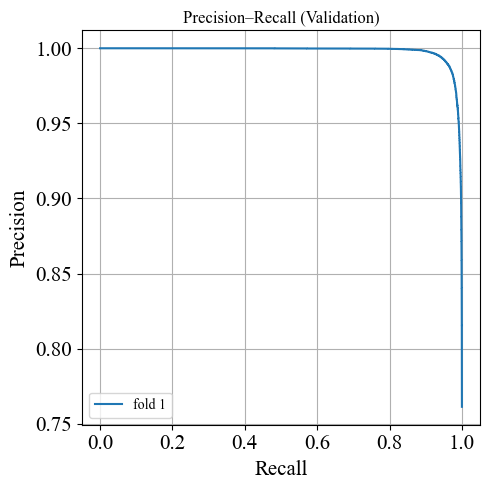

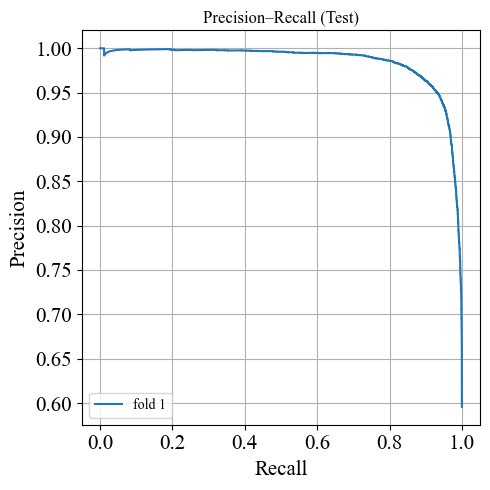

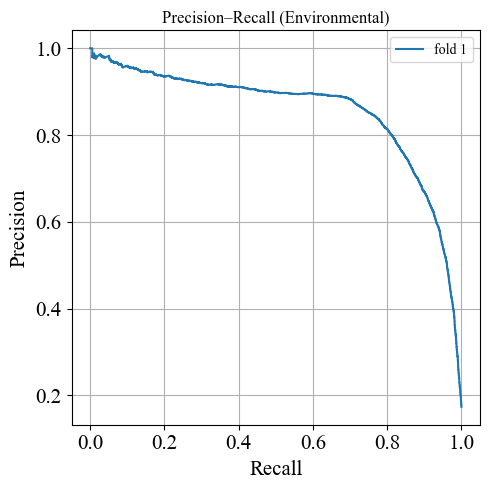

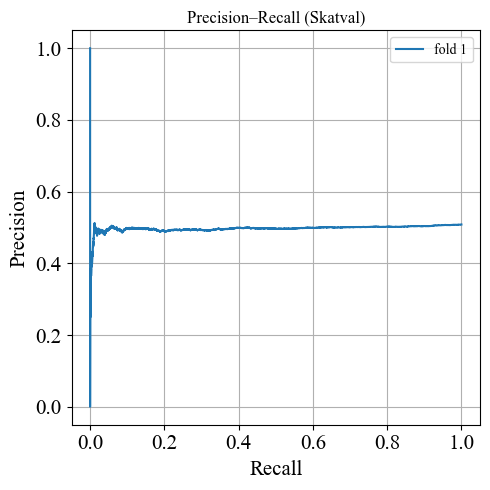

In [ ]:


functions.save_pr_curves(
    pr_curves_val,
    "Precision–Recall (Validation)",
    f"history/{timestr}/pr_curve_validation.pdf"
)

functions.save_pr_curves(
    pr_curves_test,
    "Precision–Recall (Test)",
    f"history/{timestr}/pr_curve_test.pdf"
)

functions.save_pr_curves(
    pr_curves_env,
    "Precision–Recall (Environmental)",
    f"history/{timestr}/pr_curve_environmental.pdf"
)

functions.save_pr_curves(
    pr_curves_skatval_280126,
    "Precision–Recall (Skatval)",
    f"history/{timestr}/pr_curve_skatval.pdf"
)

In [ ]:
# Load model (Keras)

# path = "history/20260203-XXXXXX/merged_model.h5"  # Update with actual path
# model = tf.keras.models.load_model(path)

In [ ]:
# # # Test and evaluate the model (Keras)

# y_pred_test = model.predict(X_test)
# # y_pred_test = postprocess_output(y_pred_test)  # If needed

# y_pred_env = model.predict(X_env)
# # y_pred_env = postprocess_output(y_pred_env)  # If needed

# average_precision = average_precision_score(y_test, y_pred_test, average='macro')

In [ ]:
# Load metrics if desired

# event_metric = load_sed_metric(f'history/20251212-162657/Event-based-dataset.pk1')
# segment_metric = load_sed_metric(f'history/20251212-162657/Segment-based-dataset.pk1')

# print_metrics(event_metrics.results_class_wise_average_metrics(), "Event-based (Env set)")
# print_metrics(segment_metrics.results_class_wise_average_metrics(), "Segment-based (Env set)")
